<a href="https://colab.research.google.com/github/JyoshanaviGudla-5/SCT_DS_1/blob/main/Task1_Population_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All Columns: ['Aruba', 'ABW', 'Population, total', 'SP.POP.TOTL', 54922, 55578, 56320, 57002, 57619, 58190, 58694, 58990, 59069, 59052, 58950, 58781, 58047, 58299, 58349, 58295, 58368, 58580, 58776, 59191, 59909, 60563, 61276, 62228, 62901, 61728, 59931, 59159, 59331, 60443, 62753, 65896, 69005, 73685, 77595, 79805, 83021, 86301, 88451, 89659, 90588, 91439, 92074, 93128, 95138, 97635, 99405, 100150, 100917, 101604, 101838, 102591, 104110, 105675, 106807, 107906, 108727, 108735, 108908, 109203, 108587, 107700, 107310, 107359, 107995, 'Unnamed: 69']
Data shape after cleaning: (211, 3)
Top 10 Countries: ['India', 'China', 'United States', 'Indonesia', 'Pakistan', 'Nigeria', 'Brazil', 'Bangladesh', 'Russian Federation', 'Ethiopia']


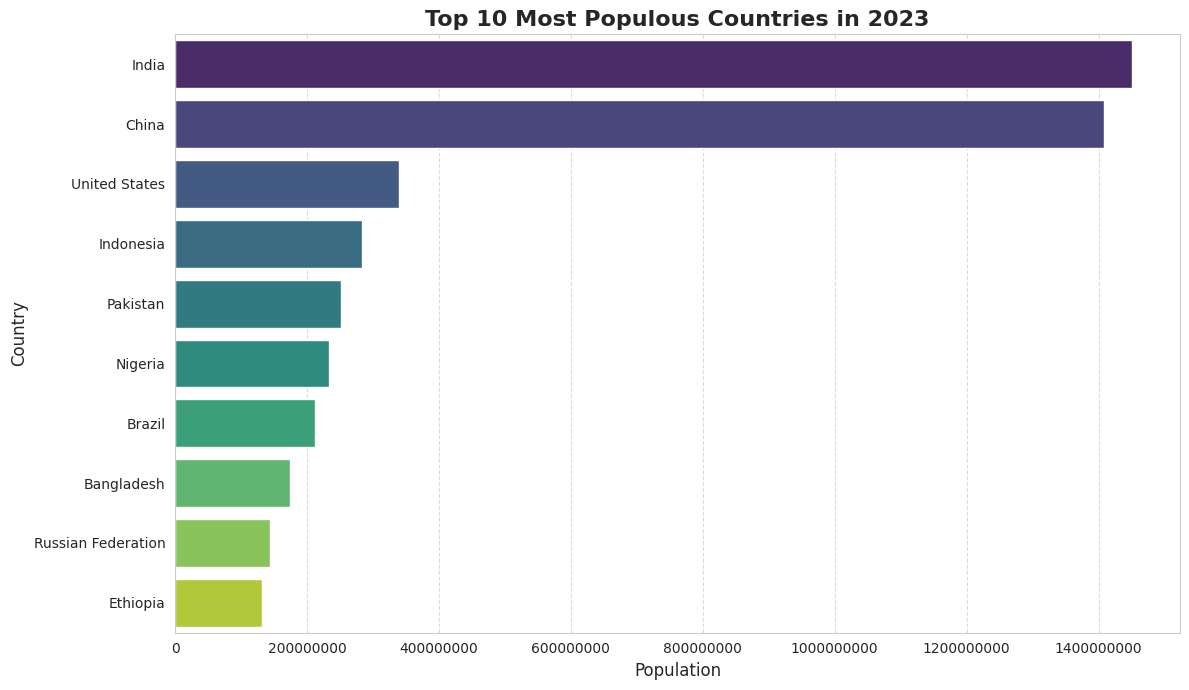

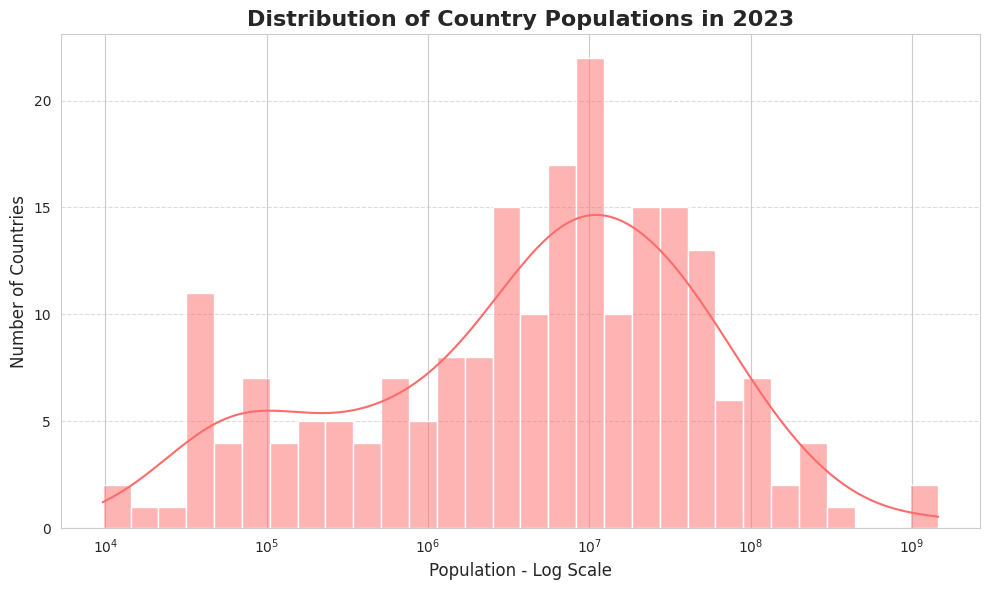

In [23]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
# 1. LOAD DATA
df = pd.read_excel('Data.csv.xls', skiprows=4)
print("All Columns:", df.columns.tolist())
df_2023 = df.iloc[:, [0, 1, -2]].copy()
df_2023.columns = ['Country', 'Code', 'Population_2023'] # Maname peru pedatam
df_2023['Population_2023'] = pd.to_numeric(df_2023['Population_2023'], errors='coerce')
df_2023.dropna(subset=['Population_2023'], inplace=True)
non_countries = [
    'WLD', 'IBD', 'IBT', 'IDA', 'IDX', 'LIC', 'LMC', 'LMY', 'MIC', 'HIC', 'UMC',
    'OED', 'EAS', 'EAP', 'ECS', 'ECA', 'EMU', 'EUU', 'LCN', 'LAC', 'MEA', 'MNA',
    'NAC', 'SAS', 'SSF', 'SSA', 'SST', 'TEA', 'TEC', 'TLA', 'TMN', 'TSA',
    'FCS', 'HPC', 'PST', 'PRE', 'LDC', 'INX', 'CSS', 'CEB', 'EAR', 'AFE', 'AFW', 'ARB'
]
df_2023 = df_2023[~df_2023['Code'].isin(non_countries)]
df_2023 = df_2023[~df_2023['Country'].str.contains('income|dividend|World|total|IBRD|IDA|Arab|Africa|Asia|Europe', case=False, na=False)]

print("Data shape after cleaning:", df_2023.shape)
print("Top 10 Countries:", df_2023.sort_values('Population_2023', ascending=False)['Country'].head(10).tolist())
#BAR CHART: TOP 10 MOST POPULOUS COUNTRIES 2023
top10 = df_2023.sort_values('Population_2023', ascending=False).head(10)
plt.figure(figsize=(12, 7))
sns.barplot(x='Population_2023', y='Country', hue='Country', data=top10, palette='viridis', legend=False)
plt.title('Top 10 Most Populous Countries in 2023', fontsize=16, fontweight='bold')
plt.xlabel('Population', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
#HISTOGRAM: POPULATION DISTRIBUTION 2023
plt.figure(figsize=(10, 6))
sns.histplot(data=df_2023, x='Population_2023', bins=30, kde=True, color='#FF6B6B', log_scale=True)
plt.title('Distribution of Country Populations in 2023', fontsize=16, fontweight='bold')
plt.xlabel('Population - Log Scale', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()